11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.9581 - loss: 0.1390
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9857 - loss: 0.0465
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9894 - loss: 0.0328
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9923 - loss: 0.0236
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9944 - loss: 0.0179
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9908 - loss: 0.0264
Test Accuracy: 0.9908000230789185
Upload handwritten digit image


Saving seven.jpeg to seven.jpeg


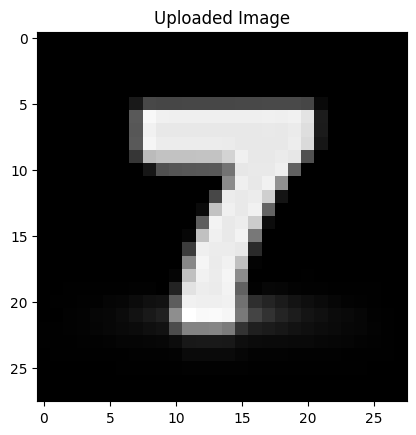

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted Digit: 7


In [1]:
# Handwritten Digit Recognizer with Image Upload (Google Colab)

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from PIL import Image

# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape((60000,28,28,1))
x_test = x_test.reshape((10000,28,28,1))

# Build CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=5)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# Upload image
print("Upload handwritten digit image")
uploaded = files.upload()

# Read uploaded image
for file_name in uploaded.keys():
    img = Image.open(file_name).convert('L')   # grayscale
    img = img.resize((28,28))

    img_array = np.array(img)

    # Invert if background is white and digit is black
    img_array = 255 - img_array

    img_array = img_array / 255.0
    img_array = img_array.reshape(1,28,28,1)

    # Show image
    plt.imshow(img_array.reshape(28,28), cmap='gray')
    plt.title("Uploaded Image")
    plt.show()

    # Predict
    prediction = model.predict(img_array)
    digit = np.argmax(prediction)

    print("Predicted Digit:", digit)